In [18]:
# Cell 1: Install required packages
!pip install neo4j pandas numpy ta scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Cell 2: Import libraries
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Technical analysis library
import ta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [20]:
# Cell 3: Neo4j Connection Setup
class Neo4jConnection:
    def __init__(self, uri, user, password):
        self.driver = GraphDatabase.driver(uri, auth=(user, password))

    def close(self):
        if self.driver is not None:
            self.driver.close()

    def query(self, query, parameters=None, db=None):
        """Execute a Cypher query and return results"""
        assert self.driver is not None, "Driver not initialized!"
        session = None
        response = None
        try:
            session = self.driver.session(database=db) if db else self.driver.session()
            response = list(session.run(query, parameters))
        except Exception as e:
            print(f"Query failed: {e}")
        finally:
            if session is not None:
                session.close()
        return response

    def execute(self, query, parameters=None, db=None):
        """Execute a Cypher query without returning results"""
        assert self.driver is not None, "Driver not initialized!"
        session = None
        try:
            session = self.driver.session(database=db) if db else self.driver.session()
            session.run(query, parameters)
        except Exception as e:
            print(f"Query execution failed: {e}")
        finally:
            if session is not None:
                session.close()

# Initialize connection
conn = Neo4jConnection(
    uri="neo4j://127.0.0.1:7687",
    user="neo4j",
    password="123456789"
)

# Test connection
try:
    result = conn.query("RETURN 'Connection successful!' as message")
    print(result[0]['message'])
except Exception as e:
    print(f"Connection failed: {e}")

Connection successful!


In [21]:
# Cell 4: Load and preprocess OHLCV data

def load_ohlcv_data(file_path):
    """
    Load OHLCV data from CSV file and standardize column names.

    Args:
        file_path: Path to CSV file containing OHLCV data

    Returns:
        DataFrame with standardized columns
    """
    # Load data
    df = pd.read_csv(file_path)

    # Print original columns to debug
    print(f"Original columns: {df.columns.tolist()}")

    # Map column names - specifically handling the ('Column',_'Ticker') format
    column_mapping = {}
    for col in df.columns:
        # Skip 'Ticker' column as it should remain unchanged
        if col == 'Ticker':
            continue

        # Extract the actual column name from the special format
        # Format is like "('Date',_'')" or "('Close',_'SIVR')"
        if "(" in col and "," in col:
            # Extract the part between the first ' and the next ,
            actual_col = col.split("'")[1] if "'" in col else col

            # Map to standard column names
            if 'Date' in actual_col:
                column_mapping[col] = 'Date'
            elif 'Open' in actual_col:
                column_mapping[col] = 'Open'
            elif 'High' in actual_col:
                column_mapping[col] = 'High'
            elif 'Low' in actual_col:
                column_mapping[col] = 'Low'
            elif 'Close' in actual_col and 'Adj' not in actual_col:
                column_mapping[col] = 'Close'
            elif 'Adj_Close' in actual_col or ('Adj' in actual_col and 'Close' in actual_col):
                column_mapping[col] = 'Adj Close'
            elif 'Volume' in actual_col:
                column_mapping[col] = 'Volume'

    # Rename columns
    df = df.rename(columns=column_mapping)

    # Print mapped columns to debug
    print(f"After mapping: {df.columns.tolist()}")

    # Convert date to datetime
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
    else:
        print("Warning: No 'Date' column found after mapping")
        # Try to use the first column that could be a date
        date_candidates = [col for col in df.columns if df[col].dtype == 'object' and df[col].iloc[0].count('-') == 2]
        if date_candidates:
            print(f"Using {date_candidates[0]} as Date column")
            df = df.rename(columns={date_candidates[0]: 'Date'})
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date').reset_index(drop=True)

    return df

# Example with your data
df = load_ohlcv_data('yf_data/TSLA_1d_1900-01-01_to_2026-02-05.csv')

df['Date'] = pd.to_datetime(df['Date'])

print(f"Loaded {len(df)} rows of data")
df.head()

Original columns: ['Ticker', "('Date',_'')", "('Adj_Close',_'TSLA')", "('Close',_'TSLA')", "('High',_'TSLA')", "('Low',_'TSLA')", "('Open',_'TSLA')", "('Volume',_'TSLA')"]
After mapping: ['Ticker', 'Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Loaded 3925 rows of data


,Ticker,Date,Adj Close,Close,High,Low,Open,Volume
0,TSLA,2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667,281494500
1,TSLA,2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333,257806500
2,TSLA,2010-07-01,1.464000,1.464000,1.728000,1.351333,1.666667,123282000
3,TSLA,2010-07-02,1.280000,1.280000,1.540000,1.247333,1.533333,77097000
4,TSLA,2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333,103003500


In [22]:
# Cell 5: Calculate technical indicators
def calculate_indicators(df):
    """Calculate technical indicators for feature engineering"""
    df = df.copy()

    # ATR (Average True Range) - volatility measure
    df['ATR'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)

    # Moving averages
    df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20)
    df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
    df['EMA_12'] = ta.trend.ema_indicator(df['Close'], window=12)

    # RSI
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)

    # Bollinger Bands
    bollinger = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
    df['BB_Upper'] = bollinger.bollinger_hband()
    df['BB_Lower'] = bollinger.bollinger_lband()
    df['BB_Middle'] = bollinger.bollinger_mavg()

    # Volume indicators
    df['Volume_SMA'] = df['Volume'].rolling(window=20).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA']

    # Price change metrics
    df['Price_Change'] = df['Close'].pct_change()
    df['Price_Change_Abs'] = df['Close'].diff()

    # Support and Resistance (simplified using rolling min/max)
    df['Support'] = df['Low'].rolling(window=20).min()
    df['Resistance'] = df['High'].rolling(window=20).max()

    # Market regime classification
    df['Regime'] = 'ranging'  # Default

    # Fill NaN values with forward fill then backward fill
    df = df.fillna(method='bfill').fillna(method='ffill')

    return df

df_with_indicators = calculate_indicators(df)
print("Technical indicators calculated")
df_with_indicators.tail()


Technical indicators calculated


,Ticker,Date,Adj Close,Close,High,Low,Open,Volume,ATR,SMA_20,...,BB_Upper,BB_Lower,BB_Middle,Volume_SMA,Volume_Ratio,Price_Change,Price_Change_Abs,Support,Resistance,Regime
3920,TSLA,2026-01-29,416.559998,416.559998,440.230011,414.619995,437.799988,81686100,14.915197,437.965001,...,457.254682,418.675320,437.965001,62073375.0,1.315960,-0.034534,-14.899994,414.619995,458.339996,ranging
3921,TSLA,2026-01-30,430.410004,430.410004,439.880005,422.700012,425.350006,82626100,15.515541,436.999501,...,455.764965,418.234037,436.999501,63750780.0,1.296080,0.033249,13.850006,414.619995,458.339996,ranging
3922,TSLA,2026-02-02,421.809998,421.809998,427.149994,414.500000,421.290009,58739500,15.543717,436.186501,...,456.071514,416.301487,436.186501,62410985.0,0.941172,-0.019981,-8.600006,414.500000,457.549988,ranging
3923,TSLA,2026-02-03,421.959991,421.959991,428.559998,413.690002,424.269989,56886500,15.495594,434.700999,...,454.171947,415.230052,434.700999,61858270.0,0.919626,0.000356,0.149994,413.690002,454.299988,ranging
3924,TSLA,2026-02-04,406.010010,406.010010,423.899994,399.179993,420.459991,74606900,16.154480,433.353500,...,456.502650,410.204351,433.353500,61133925.0,1.220385,-0.037800,-15.949982,399.179993,454.299988,ranging


In [23]:
# Cell 6: Classify market regimes
def classify_regime(row, df, idx):
    """Classify market regime based on technical indicators"""
    if pd.isna(row['ATR']) or pd.isna(row['SMA_20']):
        return 'ranging'

    # Breakout detection
    if row['Close'] > row['Resistance'] * 0.998 and row['Volume_Ratio'] > 1.5:
        return 'breakout_up'
    elif row['Close'] < row['Support'] * 1.002 and row['Volume_Ratio'] > 1.5:
        return 'breakdown'

    # Trending detection
    if row['Close'] > row['SMA_20'] and row['SMA_20'] > row['SMA_50']:
        return 'trending_up'
    elif row['Close'] < row['SMA_20'] and row['SMA_20'] < row['SMA_50']:
        return 'trending_down'

    # Consolidation/ranging
    if abs(row['Price_Change']) < row['ATR'] * 0.3:
        return 'consolidation'

    return 'ranging'

# Apply regime classification
for idx, row in df_with_indicators.iterrows():
    df_with_indicators.at[idx, 'Regime'] = classify_regime(row, df_with_indicators, idx)

print("Market regimes classified:")
print(df_with_indicators['Regime'].value_counts())

Market regimes classified:
Regime
trending_up      1446
consolidation    1440
trending_down     925
ranging            98
breakout_up        13
breakdown           3
Name: count, dtype: int64


In [24]:
# Cell 7: Clear existing graph (use before re-running the notebook)
def clear_graph(conn):
    """Clear all nodes and relationships"""
    query = "MATCH (n) DETACH DELETE n"
    conn.execute(query)
    print("Graph cleared!")

# Clear the graph to start fresh
clear_graph(conn)

Graph cleared!


In [25]:
# Cell 8: Create constraints and indexes
def create_constraints(conn):
    """Create constraints and indexes for better performance"""

    # Drop existing constraints first (in case of schema changes)
    drop_queries = [
        "DROP CONSTRAINT price_state_timestamp IF EXISTS",
        "DROP INDEX price_state_regime IF EXISTS",
        "DROP INDEX price_state_close IF EXISTS"
    ]

    for query in drop_queries:
        try:
            conn.execute(query)
        except Exception as e:
            pass  # Ignore if constraint/index doesn't exist

    # Create fresh constraints and indexes
    create_queries = [
        # Uniqueness constraint on timestamp (composite with ticker for multi-stock support)
        """CREATE CONSTRAINT price_state_unique IF NOT EXISTS
           FOR (ps:PriceState)
           REQUIRE (ps.timestamp, ps.ticker) IS UNIQUE""",

        # Index on regime for faster regime-based queries
        """CREATE INDEX price_state_regime IF NOT EXISTS
           FOR (ps:PriceState) ON (ps.regime)""",

        # Index on close price for range queries
        """CREATE INDEX price_state_close IF NOT EXISTS
           FOR (ps:PriceState) ON (ps.close)""",

        # Index on ticker for multi-stock filtering
        """CREATE INDEX price_state_ticker IF NOT EXISTS
           FOR (ps:PriceState) ON (ps.ticker)"""
    ]

    for query in create_queries:
        try:
            conn.execute(query)
            print(f"✓ Executed: {query[:60]}...")
        except Exception as e:
            print(f"Note: {str(e)[:100]}...")

create_constraints(conn)
print("\nConstraints and indexes ready!")

✓ Executed: CREATE CONSTRAINT price_state_unique IF NOT EXISTS
         ...
✓ Executed: CREATE INDEX price_state_regime IF NOT EXISTS
           FOR...
✓ Executed: CREATE INDEX price_state_close IF NOT EXISTS
           FOR ...
✓ Executed: CREATE INDEX price_state_ticker IF NOT EXISTS
           FOR...

Constraints and indexes ready!


In [26]:
# Cell 9: Create PriceState nodes
def create_price_state_nodes(conn, df, ticker='AGQ'):
    """Create PriceState nodes from OHLCV data"""

    query = """
    UNWIND $rows AS row
    CREATE (ps:PriceState {
        timestamp: datetime(row.timestamp),
        ticker: row.ticker,
        open: row.open,
        high: row.high,
        low: row.low,
        close: row.close,
        volume: row.volume,
        atr: row.atr,
        rsi: row.rsi,
        volume_ratio: row.volume_ratio,
        support: row.support,
        resistance: row.resistance,
        regime: row.regime,
        price_change_pct: row.price_change_pct,
        bb_upper: row.bb_upper,
        bb_lower: row.bb_lower,
        sma_20: row.sma_20,
        sma_50: row.sma_50,
        created_at: datetime()
    })
    """

    # Prepare data rows
    rows = []
    for idx, row in df.iterrows():
        rows.append({
            'timestamp': row['Date'].isoformat(),
            'ticker': ticker,
            'open': float(row['Open']),
            'high': float(row['High']),
            'low': float(row['Low']),
            'close': float(row['Close']),
            'volume': int(row['Volume']),
            'atr': float(row['ATR']) if not pd.isna(row['ATR']) else 0.0,
            'rsi': float(row['RSI']) if not pd.isna(row['RSI']) else 50.0,
            'volume_ratio': float(row['Volume_Ratio']) if not pd.isna(row['Volume_Ratio']) else 1.0,
            'support': float(row['Support']) if not pd.isna(row['Support']) else float(row['Low']),
            'resistance': float(row['Resistance']) if not pd.isna(row['Resistance']) else float(row['High']),
            'regime': row['Regime'],
            'price_change_pct': float(row['Price_Change']) if not pd.isna(row['Price_Change']) else 0.0,
            'bb_upper': float(row['BB_Upper']) if not pd.isna(row['BB_Upper']) else float(row['Close']),
            'bb_lower': float(row['BB_Lower']) if not pd.isna(row['BB_Lower']) else float(row['Close']),
            'sma_20': float(row['SMA_20']) if not pd.isna(row['SMA_20']) else float(row['Close']),
            'sma_50': float(row['SMA_50']) if not pd.isna(row['SMA_50']) else float(row['Close'])
        })

    # Execute in batches with progress tracking
    batch_size = 1000
    total_rows = len(rows)

    for i in range(0, total_rows, batch_size):
        batch = rows[i:i+batch_size]
        try:
            conn.execute(query, parameters={'rows': batch})
            progress = min(i + batch_size, total_rows)
            print(f"Progress: {progress}/{total_rows} nodes created ({progress/total_rows*100:.1f}%)")
        except Exception as e:
            print(f"Error in batch {i//batch_size + 1}: {e}")
            raise

    print(f"\n✓ Successfully created {total_rows} PriceState nodes for {ticker}")

    # Verify node count
    verify_query = "MATCH (ps:PriceState {ticker: $ticker}) RETURN count(ps) as count"
    result = conn.query(verify_query, parameters={'ticker': ticker})
    print(f"✓ Verified: {result[0]['count']} nodes in database")

create_price_state_nodes(conn, df_with_indicators, ticker='AGQ')

Progress: 1000/3925 nodes created (25.5%)
Progress: 2000/3925 nodes created (51.0%)
Progress: 3000/3925 nodes created (76.4%)
Progress: 3925/3925 nodes created (100.0%)

✓ Successfully created 3925 PriceState nodes for AGQ
✓ Verified: 3925 nodes in database


In [27]:
# Cell 10: Create temporal transition edges with adaptive weights
def create_transition_edges(conn):
    """Create TRANSITIONS_TO edges between consecutive price states"""
    query = """
    MATCH (ps1:PriceState), (ps2:PriceState)
    WHERE ps1.ticker = ps2.ticker
      AND duration.between(ps1.timestamp, ps2.timestamp).days = 1
    WITH ps1, ps2
    CREATE (ps1)-[t:TRANSITIONS_TO {
        weight: 1.0,
        price_change: ps2.close - ps1.close,
        price_change_pct: (ps2.close - ps1.close) / ps1.close,
        volume_ratio: toFloat(ps2.volume) / toFloat(ps1.volume),
        pattern_type: CASE
            WHEN ps2.close > ps1.resistance AND ps2.volume_ratio > 1.5 THEN 'breakout'
            WHEN ps2.close < ps1.support AND ps2.volume_ratio > 1.5 THEN 'breakdown'
            WHEN abs(ps2.close - ps1.close) / ps1.atr < 0.3 THEN 'consolidation'
            WHEN ps2.close > ps1.close THEN 'continuation_up'
            ELSE 'continuation_down'
        END,
        confidence: 0.5,
        atr_normalized_change: (ps2.close - ps1.close) / CASE WHEN ps1.atr > 0 THEN ps1.atr ELSE 1 END,
        created_at: datetime()
    }]->(ps2)
    """

    conn.execute(query)

    # Count created edges
    count_query = "MATCH ()-[t:TRANSITIONS_TO]->() RETURN count(t) as edge_count"
    result = conn.query(count_query)
    print(f"Created {result[0]['edge_count']} transition edges")

create_transition_edges(conn)

Created 254896 transition edges


In [28]:
# Cell 11: Boost breakout edge weights
def boost_breakout_weights(conn):
    """Increase weights for breakout patterns based on strength"""
    query = """
    MATCH (ps1:PriceState)-[t:TRANSITIONS_TO]->(ps2:PriceState)
    WHERE t.pattern_type = 'breakout'
    WITH ps1, ps2, t,
         (ps2.close - ps1.resistance) / ps1.atr as breakout_strength,
         ps2.volume_ratio as volume_strength
    SET t.weight = t.weight * (1 + breakout_strength * 0.5 + (volume_strength - 1) * 0.3),
        t.confidence = CASE
            WHEN breakout_strength > 2 AND volume_strength > 2 THEN 0.9
            WHEN breakout_strength > 1 AND volume_strength > 1.5 THEN 0.75
            ELSE 0.6
        END,
        t.breakout_strength = breakout_strength
    RETURN count(t) as updated_edges
    """

    result = conn.query(query)
    print(f"Boosted {result[0]['updated_edges']} breakout edges")

boost_breakout_weights(conn)

Boosted 19464 breakout edges


In [29]:
# Cell 12: Implement temporal decay for edge weights
def apply_temporal_decay(conn, lambda_decay=0.05):
    """Apply time-based decay to edge weights"""
    query = """
    MATCH (ps1:PriceState)-[t:TRANSITIONS_TO]->(ps2:PriceState)
    WITH t, duration.between(ps2.timestamp, datetime()).days as days_elapsed
    SET t.temporal_weight = t.weight * exp(-$lambda * days_elapsed),
        t.days_since = days_elapsed
    RETURN count(t) as updated_edges
    """

    result = conn.query(query, parameters={'lambda': lambda_decay})
    print(f"Applied temporal decay to {result[0]['updated_edges']} edges")

# Apply decay (adjust lambda based on your trading timeframe)
apply_temporal_decay(conn, lambda_decay=0.01)

Applied temporal decay to 254896 edges


In [30]:
# Cell 13: Create pattern similarity edges
def create_pattern_edges(conn, similarity_threshold=0.8):
    """Create edges between similar price states across different time periods"""
    query = """
    MATCH (ps1:PriceState), (ps2:PriceState)
    WHERE ps1.ticker = ps2.ticker
      AND elementId(ps1) < elementId(ps2)
      AND ps1.regime = ps2.regime
      AND abs(ps1.rsi - ps2.rsi) < 10
      AND abs(ps1.volume_ratio - ps2.volume_ratio) < 0.5
      AND abs((ps1.close - ps1.support) / (ps1.resistance - ps1.support) -
              (ps2.close - ps2.support) / (ps2.resistance - ps2.support)) < 0.2
    WITH ps1, ps2,
         1.0 - (abs(ps1.rsi - ps2.rsi) / 100.0 +
                abs(ps1.volume_ratio - ps2.volume_ratio) / 2.0) / 2.0 as similarity
    WHERE similarity > $threshold
    CREATE (ps1)-[s:SIMILAR_TO {
        similarity: similarity,
        regime: ps1.regime,
        created_at: datetime()
    }]->(ps2)
    RETURN count(s) as pattern_edges
    """

    result = conn.query(query, parameters={'threshold': similarity_threshold})
    count = result[0]['pattern_edges'] if result else 0
    print(f"Created {count} pattern similarity edges")

create_pattern_edges(conn, similarity_threshold=0.7)

Query failed: {neo4j_code: Neo.TransientError.General.OutOfMemoryError} {message: Java heap space} {gql_status: 51N59} {gql_status_description: error: system configuration or operation exception - internal resource exhaustion. The DBMS is unable to handle the request, please retry later or contact the system operator. More information is present in the logs.}
Created 0 pattern similarity edges


In [31]:
# Cell 14: Find successful breakout patterns (FIXED)
def find_successful_breakouts(conn, min_gain_pct=0.02, max_steps=5):
    """Find historical breakout patterns that led to gains"""

    # Build query with literal max_steps value (not as parameter in path)
    query = f"""
    MATCH path = (start:PriceState {{regime: 'consolidation'}})
      -[:TRANSITIONS_TO*1..{max_steps}]->(breakout:PriceState)
      -[:TRANSITIONS_TO*1..3]->(continuation:PriceState)
    WHERE breakout.regime = 'breakout_up'
      AND continuation.close > breakout.close * (1 + $min_gain)
    WITH path,
         start, breakout, continuation,
         [r in relationships(path) | r.weight] as weights,
         (continuation.close - breakout.close) / breakout.close as gain
    RETURN
        start.timestamp as consolidation_start,
        breakout.timestamp as breakout_time,
        continuation.timestamp as continuation_time,
        start.close as consolidation_price,
        breakout.close as breakout_price,
        continuation.close as continuation_price,
        gain as total_gain,
        reduce(sum = 0.0, w in weights | sum + w) / size(weights) as avg_path_weight
    ORDER BY total_gain DESC
    LIMIT 10
    """

    result = conn.query(query, parameters={'min_gain': min_gain_pct})

    if result:
        df_result = pd.DataFrame([dict(record) for record in result])
        return df_result
    return pd.DataFrame()

# Test the function
breakout_patterns = find_successful_breakouts(conn, min_gain_pct=0.01, max_steps=3)
print("Successful breakout patterns:")
if not breakout_patterns.empty:
    print(breakout_patterns)
else:
    print("No breakout patterns found matching criteria")
    print("\nTip: This might be because:")
    print("  - Not enough data with 'consolidation' -> 'breakout_up' transitions")
    print("  - min_gain_pct threshold too high")
    print("  - Need to run cells 10-11 first to create edges and boost weights")

Successful breakout patterns:
                   consolidation_start                        breakout_time  \
0  2010-10-15T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   
1  2010-10-13T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   
2  2010-10-13T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   
3  2010-12-15T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   
4  2010-10-13T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   
5  2010-10-13T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   
6  2010-12-13T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   
7  2010-10-13T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   
8  2010-10-13T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   
9  2010-12-13T00:00:00.000000000+00:00  2011-09-16T00:00:00.000000000+00:00   

                     continuation_time  consolidation_price  breakout_price  \
0  2025-12-18T00:00:0

In [32]:
# Cell 15: Generate entry signals based on current price state
def generate_entry_signals(conn, current_date, confidence_threshold=0.6):
    """Generate entry signals for a given date based on graph patterns"""
    query = """
    MATCH (current:PriceState)
    WHERE current.timestamp = datetime($current_date)

    // Find similar historical patterns
    MATCH (current)-[:SIMILAR_TO]-(similar:PriceState)
    MATCH (similar)-[t:TRANSITIONS_TO*1..3]->(future:PriceState)
    WHERE future.regime IN ['trending_up', 'breakout_up']
      AND all(r in t WHERE r.confidence > $threshold)

    WITH current, future, t,
         reduce(sum = 0.0, r in t | sum + r.weight) / size(t) as avg_weight,
         reduce(sum = 0.0, r in t | sum + r.confidence) / size(t) as avg_confidence,
         (future.close - current.close) / current.close as potential_gain

    RETURN
        current.timestamp as current_time,
        current.close as current_price,
        current.regime as current_regime,
        avg(potential_gain) as expected_gain,
        avg(avg_weight) as signal_strength,
        avg(avg_confidence) as signal_confidence,
        count(*) as pattern_count
    """

    result = conn.query(query, parameters={
        'current_date': current_date,
        'threshold': confidence_threshold
    })

    return result

# Example: Generate signal for a specific date (adjust to your data)
signals = generate_entry_signals(conn, '2026-01-09T00:00:00', confidence_threshold=0.5)
print(signals)


[]


In [33]:
# Cell 16: Visualize graph statistics
def get_graph_statistics(conn):
    """Get comprehensive graph statistics"""
    stats = {}

    # Node count
    node_query = "MATCH (n:PriceState) RETURN count(n) as node_count"
    stats['nodes'] = conn.query(node_query)[0]['node_count']

    # Edge count by type
    edge_query = """
    MATCH ()-[r]->()
    RETURN type(r) as edge_type, count(r) as count
    """
    edge_results = conn.query(edge_query)
    stats['edges'] = {record['edge_type']: record['count'] for record in edge_results}

    # Regime distribution
    regime_query = """
    MATCH (ps:PriceState)
    RETURN ps.regime as regime, count(*) as count
    ORDER BY count DESC
    """
    regime_results = conn.query(regime_query)
    stats['regimes'] = {record['regime']: record['count'] for record in regime_results}

    # Average weights
    weight_query = """
    MATCH ()-[t:TRANSITIONS_TO]->()
    RETURN
        avg(t.weight) as avg_weight,
        max(t.weight) as max_weight,
        min(t.weight) as min_weight,
        avg(t.confidence) as avg_confidence
    """
    weight_result = conn.query(weight_query)[0]
    stats['weights'] = dict(weight_result)

    return stats

stats = get_graph_statistics(conn)
print("=== Graph Statistics ===")
print(f"Total Nodes: {stats['nodes']}")
print(f"\nEdges by Type:")
for edge_type, count in stats['edges'].items():
    print(f"  {edge_type}: {count}")
print(f"\nRegime Distribution:")
for regime, count in stats['regimes'].items():
    print(f"  {regime}: {count}")
print(f"\nEdge Weights:")
for key, value in stats['weights'].items():
    print(f"  {key}: {value:.4f}")


=== Graph Statistics ===
Total Nodes: 3925

Edges by Type:
  TRANSITIONS_TO: 254896

Regime Distribution:
  trending_up: 1446
  consolidation: 1440
  trending_down: 925
  ranging: 98
  breakout_up: 13
  breakdown: 3

Edge Weights:
  avg_weight: inf
  max_weight: inf
  min_weight: 1.0000
  avg_confidence: 0.5220


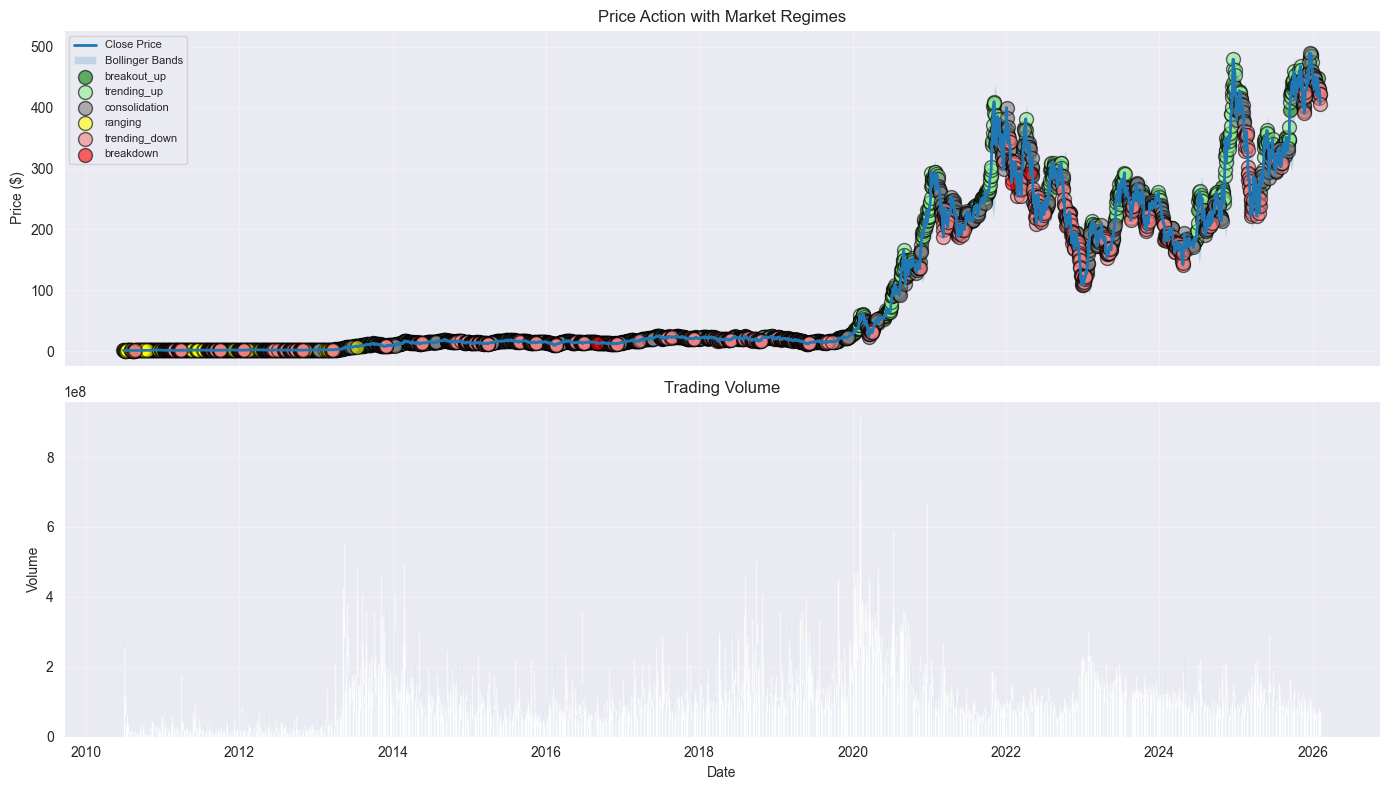

In [34]:
# Cell 17: Visualize price states and regimes
def visualize_price_regimes(df):
    """Visualize price action with regime coloring"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Price chart
    ax1.plot(df['Date'], df['Close'], label='Close Price', linewidth=2)
    ax1.fill_between(df['Date'], df['BB_Lower'], df['BB_Upper'], alpha=0.2, label='Bollinger Bands')

    # Color code by regime
    regime_colors = {
        'breakout_up': 'green',
        'trending_up': 'lightgreen',
        'consolidation': 'gray',
        'ranging': 'yellow',
        'trending_down': 'lightcoral',
        'breakdown': 'red'
    }

    for regime, color in regime_colors.items():
        mask = df['Regime'] == regime
        if mask.any():
            ax1.scatter(df[mask]['Date'], df[mask]['Close'],
                       c=color, label=regime, s=100, alpha=0.6, edgecolors='black')

    ax1.set_ylabel('Price ($)')
    ax1.set_title('Price Action with Market Regimes')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Volume chart
    ax2.bar(df['Date'], df['Volume'], color='steelblue', alpha=0.6)
    ax2.set_ylabel('Volume')
    ax2.set_xlabel('Date')
    ax2.set_title('Trading Volume')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

visualize_price_regimes(df_with_indicators)


In [35]:
# Cell 18: Close connection when done
# Run this cell when you're finished
conn.close()
print("Connection closed")


Connection closed
